In [1]:
%pip install diffrax

/Users/ebilionis/Dropbox/PredictiveScienceLab/mybooks/me697-book/advanced-scientific-machine-learning/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

import time
import jax
jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import jax.random as jr
from jax import vmap, jit, value_and_grad
from dataclasses import dataclass
import equinox as eqx
import optax
import numpy as np
from typing import Tuple
from diffrax import diffeqsolve, Euler, Heun, SaveAt, ODETerm
from functools import partial

key = jr.PRNGKey(0)

# Example: A Dynamical System with Multiple Observed Trajectories




We infer the parameters of a deterministic Duffing oscillator from multiple noisy trajectories. The equations of motion are



\begin{align*}
   \dot{x} &= v \\
   \dot{v} &= -2\xi\omega_n v - \omega_n^2 x - \beta x^3 + \gamma \sin(\omega t). \\
   \\
   x(0) &= x_0, \\
   v(0) &= v_0.
\end{align*}


where $x$ is the position, $v$ is the velocity, and $x_0$ and $v_0$ are their initial values. The parameter $\xi$ is the damping ratio, $\omega_n$ is the natural frequency, and $\beta$ is the nonlinear stiffness coefficient. The known external forcing is $\gamma \sin(\omega t)$. We subtract this known forcing from the measured acceleration. Thus the observed signal is $a_{\mathrm{red}}(t)=\dot v(t)-\gamma\sin(\omega t)=-2\xi\omega_n v(t)-\omega_n^2x(t)-\beta x(t)^3$, corrupted by additive Gaussian noise with known variance. The plots label this forcing-subtracted quantity as reduced acceleration.

Our goal is to infer $\mathbf{\theta} = (x_0, v_0, \omega_n, \xi, \beta)$ for a target system. Amortized variational inference (AVI) learns a global map from an observed trajectory to an approximate posterior over $\mathbf{\theta}$. Training this map is expensive, but a new trajectory requires only a forward pass through the trained inference network.

We first implement the system dynamics.

In [4]:
# Duffing constants
class DuffingConsts(eqx.Module):
    gamma: float = eqx.field(static=True)
    omega: float = eqx.field(static=True)

# Vector field
def vector_field(t, y, args):
    """Duffing oscillator dynamics.

    Args:
        t: Current time
        y: State [x, v]
        args: (theta, gamma, omega) where theta = [x0, v0, wn, xi, beta]
    """
    theta, gamma, omega = args
    _, _, wn, xi, beta = theta[:5]

    # Compute control input
    u = gamma * jnp.sin(omega * t)

    x, v = y[0], y[1]
    return jnp.array([
        v,
        -2*xi*wn*v - wn**2*x - beta*x**3 + u
    ])

# ODE solver
solver = Heun() # more accurate and stable than Euler()
term = ODETerm(vector_field)
@jit
def solve_ode(theta: jnp.ndarray, ts: jnp.ndarray, consts) -> jnp.ndarray:
    """Solve Duffing ODE with given parameters and control input.

    Args:
        theta: Parameters [x0, v0, wn, xi, beta]
        ts: Time points
        consts: Excitation input constants, including gamma & omega

    Returns:
        xs: States (position and velocity) at time points
    """
    gamma = consts.gamma
    omega = consts.omega
    x0, v0 = theta[0], theta[1]
    saveat = SaveAt(ts=ts)

    sol = diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=jnp.array([x0, v0]),
        args=(theta, gamma, omega),
        saveat=saveat,
    )
    return sol.ys

# Observation function
def observation_duffing(theta: jnp.ndarray, xs: jnp.ndarray) -> jnp.ndarray:
    """Compute observation (forcing-subtracted acceleration) from states.

    Args:
        theta: Parameters [x0, v0, wn, xi, beta]
        xs: States position and velocity

    Returns:
        acs: Forcing-subtracted accelerations
    """
    _, _, wn, xi, beta = theta[:5]
    acs = -2 * xi * wn * xs[:, 1] - wn ** 2 * xs[:, 0] - beta * xs[:, 0] ** 3
    return acs

## Problem Constants and Target System
All simulated batches use evenly spaced measurements over a fixed 15-second window and the same sinusoidal excitation. The global settings are:

In [5]:
# Time parameters
t0 = 0.0
t1 = 15.0
dt = 0.04
ts = jnp.arange(t0, t1 + dt, dt)
t_len = len(ts)

# Control input constants
consts = DuffingConsts(gamma=0.8, omega=1.25)

# Observation noise parameter
sigma_meas = 1.0

# System parameters
list_theta = ['x0', 'v0', 'wn', 'xi', 'beta']
n_params = len(list_theta)

The target system uses the following parameters.

In [6]:
# Generate target trajectory
actual_theta = jnp.array([0.5, 0.1, 3.0, 0.2, 0.0])
print(
    f"True parameters: "
    f"x0={actual_theta[0]:.2f}, "
    f"v0={actual_theta[1]:.2f}, "
    f"wn={actual_theta[2]:.2f}, "
    f"xi={actual_theta[3]:.2f}, "
    f"beta={actual_theta[4]:.2f}"
)

# Solve ODE
target_xs = solve_ode(actual_theta, ts, consts)

# Compute noisy forcing-subtracted acceleration
target_obs = observation_duffing(actual_theta, target_xs)
target_obs = target_obs + jr.normal(key, target_obs.shape) * sigma_meas

True parameters: x0=0.50, v0=0.10, wn=3.00, xi=0.20, beta=0.00


The resulting target trajectory is shown below.

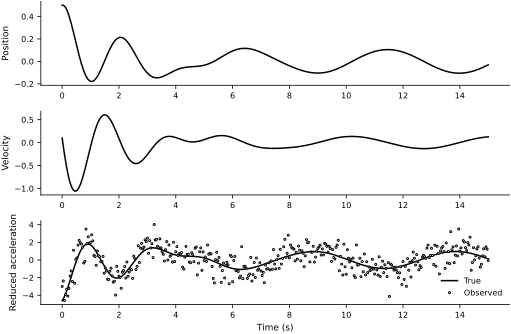

In [7]:
# Visualize target system
fig, axes = plt.subplots(3, 1, figsize=FIGURE_SIZES["full_standard"])

axes[0].plot(ts, target_xs[:, 0], color='black', linewidth=1.5)
axes[0].set_ylabel('Position')

axes[1].plot(ts, target_xs[:, 1], color='black', linewidth=1.5)
axes[1].set_ylabel('Velocity')

acs_true = observation_duffing(actual_theta, target_xs)
axes[2].plot(ts, acs_true, color='black', linewidth=1.5, label='True')
axes[2].plot(ts, target_obs, linestyle='none', marker='o', markersize=2,
             markerfacecolor='white', markeredgecolor='black', label='Observed')
axes[2].set_ylabel('Reduced acceleration')
axes[2].set_xlabel('Time (s)')
axes[2].legend()

plt.tight_layout()
for ax in axes:
    finalize_axes(keep_box=False)

The reduced-acceleration observations contain substantial noise.

## Formulation of the Problem

### Prior Definition

We assign priors that encode plausible parameter scales. Lognormal priors enforce positivity for $\omega_n$ and $\xi$:

$$
\begin{aligned}
x_0 &\sim \mathcal{N}(0, 1), \\
v_0 &\sim \mathcal{N}(0, 1), \\
\beta &\sim \mathcal{N}(0, 0.5^2), \\
\omega_n &\sim \text{LogNormal}(1.2, 0.3^2), \\
\xi &\sim \text{LogNormal}(-1.9, 0.6^2).
\end{aligned}
$$

The following class evaluates and samples both types of prior distribution.

In [8]:
def normal_logpdf(x, mu, sigma):
    """Compute log N(x | mu, sigma^2) elementwise."""
    sigma_safe = jnp.maximum(sigma, 1e-6)
    z = (x - mu) / sigma_safe
    return -0.5 * z**2 - jnp.log(sigma_safe) - 0.5 * jnp.log(2.0 * jnp.pi)


@jax.tree_util.register_pytree_node_class
@dataclass(frozen=True)
class PriorSpec:
    """
    Prior specification for model parameters using unconstrained variables z.

    type_code:
        0 -> Normal prior on theta (identity transform)
        1 -> LogNormal prior on theta (z = log theta)
    """
    type_code: Tuple[int, ...]
    mu: jnp.ndarray
    sigma: jnp.ndarray

    def tree_flatten(self):
        """Tell JAX how to flatten this object into arrays for JIT/Vmap."""
        children = (self.mu, self.sigma)
        aux_data = self.type_code
        return children, aux_data

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        """Reconstruct object after JAX transformations."""
        mu, sigma = children
        return cls(type_code=aux_data, mu=mu, sigma=sigma)

    @property
    def is_lognormal(self):
        """Boolean mask indicating which parameters use LogNormal priors."""
        return jnp.array(self.type_code, dtype=jnp.int32) == 1

    def log_prior_z(self, z_unconstrained):
        """Prior in unconstrained space."""
        return normal_logpdf(z_unconstrained, self.mu, self.sigma)

    def log_prior_theta(self, theta_constrained):
        """Prior in constrained space."""
        theta = jnp.asarray(theta_constrained)

        # Normal on theta
        logp_normal = normal_logpdf(theta, self.mu, self.sigma)

        # LogNormal on theta: log(theta) ~ Normal(mu, sigma)
        is_pos = theta > 0
        log_theta = jnp.where(is_pos, jnp.log(theta), 0.0)

        logp_lognorm_valid = normal_logpdf(
            log_theta, self.mu, self.sigma) - log_theta
        logp_lognorm = jnp.where(is_pos, logp_lognorm_valid, -jnp.inf)
        return jnp.where(self.is_lognormal, logp_lognorm, logp_normal)

    def total_log_prior_z(self, z_unconstrained):
        """Compute the total log prior log p(z) summed over all parameters."""
        return jnp.sum(self.log_prior_z(z_unconstrained))

    def total_log_prior_theta(self, theta_constrained):
        """Compute total log p(theta) summed over parameters."""
        return jnp.sum(self.log_prior_theta(theta_constrained))

    def sample_theta(self, key, n_samples: int):
        """Draw samples from the prior in constrained parameter space."""
        eps = jr.normal(key, (n_samples, self.mu.shape[0]))
        z_samples = self.mu[None, :] + self.sigma[None, :] * eps
        return jnp.where(self.is_lognormal[None, :],
                        jnp.exp(z_samples),
                        z_samples)

@partial(jit, static_argnames=["n_samples"])
def sample_theta_from_prior(prior: PriorSpec, key, n_samples: int):
    """Sample parameters from the prior in constrained space."""
    return prior.sample_theta(key, n_samples)

In [9]:
# Define prior on parameters
prior_types = (0, 0, 1, 1, 0) # 0 = Normal, 1 = LogNormal
prior_mus = jnp.array([0.0, 0.0, 1.2, -1.9, 0.0], dtype=jnp.float32)
prior_sigmas = jnp.array([1.0, 1.0, 0.3, 0.6, 0.5], dtype=jnp.float32)

prior = PriorSpec(type_code=prior_types, mu=prior_mus, sigma=prior_sigmas)

We next simulate trajectories using parameters sampled from the prior.
Divergent trajectories are excluded from visualization and training, so we generate about 30% more than ``n_trajectories`` and retain the requested number of stable trajectories.
The observation scale ``scale_obs`` is computed from these simulations and used later to improve numerical conditioning during training.
These bounds select a subset of the prior predictive trajectories. The training distribution is therefore the accepted subset; accuracy is assessed for trajectories in that range. The fixed-size minibatch routine repeats an accepted trajectory when its buffer has too few accepted draws.

In [10]:
def generate_single_trajectory(key, prior, ts, consts):
    """Generate a single trajectory of the system.

    Uses the divergence checking for data generation.

    Args:
        key: JAX random key
        prior: Prior object
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency

    Returns:
        obs: Noisy observations of forcing-subtracted acceleration
        is_valid: Boolean indicating whether the trajectory is non-divergent
    """
    # Sample model parameters from the prior (constrained space)
    key, theta_key, noise_key = jr.split(key, 3)
    theta = sample_theta_from_prior(prior, theta_key, 1)[0]

    # Solve the ODE to obtain state trajectory
    xs = solve_ode(theta, ts, consts)
    acs = observation_duffing(theta, xs)
    noise = jr.normal(noise_key, acs.shape) * sigma_meas
    obs = acs + noise

    # Check whether the trajectory diverged or numerically unstable
    is_div = is_divergent_trajectory(xs, obs)
    return xs, obs, ~is_div


@partial(jit, static_argnames=("minibatch_size",))
def generate_minibatch_trajectories(key, prior, ts, consts, minibatch_size):
    """Generate a minibatch of valid trajectories.

    Trajectories that diverge are discarded. Extra samples are
    generated to ensure that enough valid trajectories are collected.

    Args:
        key: JAX random key
        prior: Prior object
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency
        minibatch_size: Number of valid trajectories to return

    Returns:
        obs_batch: Batch of observations
    """
    # Generate up to 1.3x to account for divergent cases
    buffer = int(minibatch_size * 1.3)

    # Generate trajectories
    keys = jr.split(key, buffer)
    _, obs_batch, valid_mask = vmap(
        lambda k, prior, ts, consts: generate_single_trajectory(
            k, prior, ts, consts),
        in_axes=(0, None, None, None),
    )(keys, prior, ts, consts)

    # Ensure at least one valid trajectory exists
    any_valid = jnp.any(valid_mask)
    fallback = jnp.where(any_valid, jnp.argmax(valid_mask), 0)

    # Select indices of valid trajectories
    idx = jnp.nonzero(valid_mask, size=minibatch_size, fill_value=fallback)[0]
    return obs_batch[idx]


@partial(jit,
    static_argnames=("threshold_pos", "threshold_vel", "threshold_acc"),)
def is_divergent_trajectory(
    xs, obs, threshold_pos=5.0, threshold_vel=10.0, threshold_acc=50.0):
    """
    Check whether a simulated trajectory is numerically unstable or divergent.

    Args:
        xs: State trajectory (position, velocity)
        obs: Observation trajectory
        threshold_pos: Maximum allowed absolute position
        threshold_vel: Maximum allowed absolute velocity
        threshold_acc: Maximum allowed absolute observation value

    Returns:
        is_divergent: Boolean indicating whether the trajectory is invalid
    """
    # Extract position and velocity
    pos = xs[:, 0]
    vel = xs[:, 1]

    # Compute maximum absolute values
    pos_max = jnp.max(jnp.abs(pos))
    vel_max = jnp.max(jnp.abs(vel))
    obs_max = jnp.max(jnp.abs(obs))

    # Check for NaNs or infinities
    xs_finite = jnp.all(jnp.isfinite(xs))
    obs_finite = jnp.all(jnp.isfinite(obs))

    return (
        (~xs_finite) | (~obs_finite)
        | ((pos_max > threshold_pos) | (vel_max > threshold_vel))
        | (obs_max > threshold_acc)
    )

Below, we show the examples of hidden state trajectories (position and velocity) together with their corresponding noisy reduced-acceleration observations.

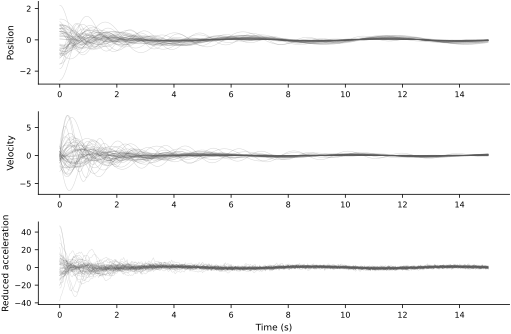

In [11]:
# Generate trajectories from prior
key, subkey = jr.split(key)
n_trajectories = 50
n_trajectories_buffer = int(n_trajectories * 1.3)

# Sample trajectories
key_traj = jr.split(subkey, n_trajectories_buffer)
results = vmap(generate_single_trajectory,
               in_axes=(0, None, None, None))(key_traj, prior, ts, consts)
xs_batch, obs_batch, valid_mask = results

# Get valid trajectories
valid_indices = jnp.where(valid_mask)[0][:n_trajectories]
xs_valid =  xs_batch[valid_indices]
obs_valid = obs_batch[valid_indices]
scale_obs = float(jax.device_get(obs_valid.std()))

# Plot trajectories
fig, axes = plt.subplots(3, 1, figsize=FIGURE_SIZES["full_standard"])
for i in range(n_trajectories):
    axes[0].plot(ts, xs_valid[i, :, 0], color='0.35', alpha=0.25, linewidth=0.5)
    axes[1].plot(ts, xs_valid[i, :, 1], color='0.35', alpha=0.25, linewidth=0.5)
    axes[2].plot(ts, obs_valid[i], color='0.35', alpha=0.20, linewidth=0.5)

axes[0].set_ylabel('Position')
axes[1].set_ylabel('Velocity')
axes[2].set_ylabel('Reduced acceleration')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
for ax in axes:
    finalize_axes(keep_box=False)

The prior produces varied stable behavior without being overly restrictive.

### Guide Setup

For the guide $q(\theta)$, we use a [multivariate Gaussian with full covariance](../vi/01_basics.md). A transformation $z = T(\theta)$ maps the constrained physical parameters $\theta$ to unconstrained coordinates $z$:

$$
q_{\phi}(\theta)
= \tilde{q}_{\phi}\!\big(T(\theta)\big)\,\left|\det J_T(\theta)\right|
= \mathcal{N}\!\big(T(\theta)\mid \mu_{\phi},\, L_{\phi}L_{\phi}^{\mathsf T}\big)\,
\left|\det J_T(\theta)\right|.
$$

where $L_{\phi}$ is lower triangular (Cholesky decomposition), parameterized by ${\phi}$, and
$J_T(\theta) = \frac{\partial z}{\partial \theta}$ denotes the Jacobian of the transformation
from the constrained parameter space to the unconstrained space.

In [12]:
class FullRankGaussianGuide(eqx.Module):
    """Multivariate normal guide with variational parameters phi."""
    guide_params: jnp.ndarray
    num_model_params: int = eqx.field(static=True, default=None)

    def __post_init__(self):
        expected = self.get_num_guide_params(self.num_model_params)
        if self.guide_params.shape[0] != expected:
            raise ValueError(
                "The length of phi is not consistent with number of parameters."
            )

    def logprob(self, model_params):
        """The log probability density of the guide."""
        return jax.scipy.stats.multivariate_normal.logpdf(
            model_params, self.mu, self.Sigma
        )

    def sample(self, key, num_samples):
        """Samples from the guide."""
        return jr.multivariate_normal(
            key, self.mu, self.Sigma, shape=(num_samples,)
        )

    def forward(self, epsilon):
        """Reparameterization trick: transform N(0,I) sample to guide sample."""
        return self.mu + jnp.dot(self.L, epsilon)

    @property
    def mu(self):
        """The mean of the guide."""
        return self.guide_params[: self.num_model_params]

    @property
    def Sigma(self):
        """The covariance of the guide."""
        L = self.L
        return jnp.dot(L, L.T)

    @property
    def L(self):
        """The Cholesky factor of the covariance of the guide."""
        n = self.num_model_params

        # Diagonal (positive via exp)
        ell = jnp.exp(self.guide_params[n : 2 * n])
        L = jnp.diag(ell)

        # Strictly lower-triangular entries
        tril_idx = jnp.tril_indices(n, -1)
        L = L.at[tril_idx].set(self.guide_params[2 * n :])
        return L

    @classmethod
    def from_mean_covariance(cls, mu, Sigma):
        """Initialize guide_params from a given mean and covariance."""
        L = jnp.linalg.cholesky(Sigma)
        ell = jnp.diag(L)
        tri = L[jnp.tril_indices(L.shape[0], -1)]
        guide_params = jnp.hstack([mu, jnp.log(ell), tri])
        return cls(guide_params=guide_params, num_model_params=mu.shape[0])

    @staticmethod
    def get_num_guide_params(num_model_params):
        """Return the number of guide parameters."""
        num_mu_params = num_model_params
        num_L_params = num_model_params * (num_model_params + 1) // 2
        return num_mu_params + num_L_params

In [13]:
# Guide Transform: z (unconstrained) <-> theta (constrained)
@jax.tree_util.register_pytree_node_class
@dataclass(frozen=True)
class ConstraintTransform:
    """
    Constraint transform used by the guide:
      z ∈ R^d  -->  theta in constrained space

    type_code per-dimension:
      0 -> identity: theta = z
      1 -> exp:      theta = exp(z)   (positive constraint)
    """
    type_code: Tuple[int, ...]

    def tree_flatten(self):
        children = ()
        aux_data = self.type_code
        return children, aux_data

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        del children
        return cls(type_code=aux_data)

    @property
    def is_exp(self):
        return jnp.array(self.type_code, dtype=jnp.int32) == 1

    def forward(self, z):
        """z -> theta"""
        return jnp.where(self.is_exp, jnp.exp(z), z)

    def inverse(self, theta):
        """theta -> z"""
        theta_pos = jnp.maximum(theta, jnp.finfo(theta.dtype).tiny)
        return jnp.where(self.is_exp, jnp.log(theta_pos), theta)

    def log_abs_det_jacobian(self, z):
        """log |det(d theta / d z)| elementwise for z -> theta"""
        # identity: 0, exp: log|exp(z)| = z
        return jnp.where(self.is_exp, z, 0.0)

    def total_log_abs_det_jacobian(self, z):
        return jnp.sum(self.log_abs_det_jacobian(z))


# Helper for transforming between constrained and unconstrained spaces
@jit
def z_to_theta(constraint: ConstraintTransform, z):
    """Transform parameters to constrained space."""
    return constraint.forward(z)

@jit
def theta_to_z(constraint: ConstraintTransform, theta):
    """Transform parameters to unconstrained space."""
    return constraint.inverse(theta)

@jit
def total_logdet_z_to_theta(constraint: ConstraintTransform, z):
    """Compute total log |det(d theta/d z)| summed over parameters."""
    return constraint.total_log_abs_det_jacobian(z)

In [14]:
# Define constraint transform on guide parameters (parameterization)
constraint = ConstraintTransform(type_code=prior_types)

### ELBO

Standard VI maximizes the ELBO with respect to $\phi$:

$$\mathrm{ELBO}(\phi)
=
\mathbb{E}_{q_{\phi}(\theta)}
\big[
\log p(\mathbf{y}\mid \theta)
+ \log p(\theta)
- \log q_{\phi}(\theta)
\big].$$

The implementation combines three terms:
- $p(\theta)$: the prior over system parameters ($\theta$)
- $p(\mathbf{y} \mid \theta)$: the likelihood of the observed system trajectory ($\mathbf{y}$)
- $q_{\phi}(\theta)$: the variational guide distribution, whose entropy discourages collapse to a point estimate

To estimate the likelihood term, we draw ``n_mc_samples`` reparameterized samples from the guide, solve the ODE for each parameter set, and compare the resulting trajectories with the observed data vector $\mathbf{y}$.

In [15]:
@jit
def log_likelihood(obs, ts, consts, theta, sigma_meas):
    """Compute log likelihood under Gaussian measurement noise."""
    # Solve ODE
    xs = solve_ode(theta, ts, consts)
    acc_pred = observation_duffing(theta, xs)

    # Log likelihood
    residuals = obs - acc_pred
    n = obs.shape[0]

    sigma2 = sigma_meas**2
    log_norm = -0.5 * n * jnp.log(2.0 * jnp.pi * sigma2)
    quad = -0.5 * jnp.sum(residuals**2) / sigma2
    return log_norm + quad

def elbo_single_sample(prior, constraint, obs, ts, consts,
                       z_sample, guide, sigma_meas):
    """ELBO computation for a single MC sample.

    Args:
        prior: Prior object
        constraint: Constraint transform
        obs: Observations over time
        ts: Time grid
        consts: Excitation input constants, including amplitude and frequency
        z_sample: One parameter sample in unconstrained space
        guide: FullRankGaussianGuide instance
        sigma_meas: Measurement noise std

    Returns:
        elbo_val: scalar ELBO value
    """
    # Transform to constrained space
    theta_sample = constraint.forward(z_sample)

    # Log prior
    log_prior = prior.total_log_prior_theta(theta_sample)

    # Log likelihood
    log_lik = log_likelihood(obs, ts, consts, theta_sample, sigma_meas)

    # Log variational posterior using guide
    log_q_val = guide.logprob(z_sample)

    # Log det jacobian
    log_det_jac = constraint.total_log_abs_det_jacobian(z_sample)

    # ELBO term
    elbo_val = log_prior + log_lik - log_q_val + log_det_jac
    return elbo_val


@partial(jit, static_argnames=['n_params'])
def elbo_batch_reparameterized(prior, constraint, obs, ts, consts,
                                          guide_params, sigma_meas,
                                          epsilon_batch, n_params=5):
    """Compute mean ELBO over MC samples using reparameterization.

    Args:
        prior: Prior object
        constraint: Constraint transform
        obs: Observations over time
        ts: Time grid
        consts: Excitation input constants, including amplitude and frequency
        guide_params: Packed parameters for FullRankGaussianGuide.
        sigma_meas: Measurement noise std
        epsilon_batch: Standard normal samples
        n_params: Number of parameters

    Returns:
        mean ELBO over MC samples
    """
    # Create guide from parameters
    guide = FullRankGaussianGuide(guide_params, n_params)

    # Reparameterization
    z_samples = vmap(guide.forward)(epsilon_batch)

    # Compute ELBO for each sample
    def compute_single_elbo(z_sample):
        return elbo_single_sample(
            prior, constraint, obs, ts, consts, z_sample, guide, sigma_meas
        )

    # Compute ELBO for all MC samples
    elbos = vmap(compute_single_elbo)(z_samples)

    # Filter and average
    finite_elbos = jnp.where(jnp.isfinite(elbos), elbos, -1e9)
    return jnp.mean(finite_elbos)

### Variational inference implementation

The ``mode`` argument selects either standard VI for one target trajectory or AVI using a trained inference network.

In [16]:
def run_vi(mode, key, obs, ts, consts, sigma_meas, prior, constraint,
           inference_model=None, minibatch_size=None, n_steps=1000,
           n_mc_samples=5, learning_rate=0.0001):
    """Run variational inference (in standard or amortized mode).

    Args:
        mode: "standard" or "amortized"
        key: Random key
        obs: Observations for standard VI (unused for amortized mode)
        ts: Time points
        consts: Excitation input constants, including amplitude and frequency
        sigma_meas: Measurement noise std
        prior: Prior class
        constraint: Constraint transform of the guide
        inference_model: NeuralNetworkEncoder (for amortized mode)
        minibatch_size: Batch size (for amortized mode)
        n_steps: Number of optimization steps
        n_mc_samples: Number of Monte Carlo samples for ELBO
        learning_rate: Learning rate

    Returns:
        For standard VI: (guide, elbo_history, total_time)
        For amortized VI: (trained_model, elbo_history, total_time)
    """
    # Time the process
    t_start = time.perf_counter()

    prior_mus = prior.mu
    prior_sigmas = prior.sigma
    n_params = prior_mus.shape[0]

    # Loss function for single trajectory
    @jit
    def single_trajectory_loss(guide_params_single, obs_single, epsilon):
        """Compute negative ELBO for a single trajectory.

        Args:
            guide_params_single: guide parameters
            obs_single: observations
            epsilon: standard normal samples
        """
        return -elbo_batch_reparameterized(
            prior, constraint, obs_single, ts, consts,
            guide_params_single, sigma_meas, epsilon, n_params)

    # Mode specific setup
    if mode == "standard":
        # Initialize guide from prior
        mean_init = prior_mus
        sigma_init = jnp.diag(prior_sigmas ** 2)
        guide = FullRankGaussianGuide.from_mean_covariance(mean_init, sigma_init)
        params = guide.guide_params  # Optimize guide params directly

        # Loss and gradient function
        def loss_fn(p, obs_data, epsilon_data):
            return single_trajectory_loss(p, obs_data, epsilon_data)
        loss_and_grad = jit(value_and_grad(loss_fn))

        # Data generator (always use same trajectory)
        def get_batch_data(k):
            k, subkey = jr.split(k)
            epsilon = jr.normal(subkey, shape=(n_mc_samples, n_params))
            return k, obs, epsilon

        # Final output constructor
        def get_result(p):
            return FullRankGaussianGuide(p, n_params)

    elif mode == "amortized":
        params = inference_model  # Optimize neural network

        # Batch loss function
        def loss_fn(model, obs_batch, epsilon_batch):
            """Compute mean loss over batch of trajectories.

            Args:
                model: NeuralNetworkEncoder
                obs_batch: observations
                epsilon_batch: standard normal samples
            """
            def process_single(obs, epsilon):
                mean, L_flat = model(obs)
                guide_params = jnp.concatenate([mean, L_flat])
                return single_trajectory_loss(guide_params, obs, epsilon)
            losses = vmap(process_single)(obs_batch, epsilon_batch)
            return jnp.mean(losses)

        loss_and_grad = eqx.filter_value_and_grad(loss_fn)

        # Data generator
        def get_batch_data(k):
            k, batch_key, eps_key = jr.split(k, 3)
            obs_batch = generate_minibatch_trajectories(
                batch_key, prior, ts, consts, minibatch_size)
            epsilon = jr.normal(eps_key,
                                shape=(minibatch_size, n_mc_samples, n_params))
            return k, obs_batch, epsilon

        # Final output
        def get_result(p):
            return p

    else:
        raise ValueError(f"Unknown mode: {mode}. Must be 'standard/amortized'")

    # Optimizer
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.apply_if_finite(optax.adam(learning_rate=learning_rate), 100),)
    opt_state = optimizer.init(eqx.filter(params, eqx.is_array))

    # Optimization loop
    elbo_history = []
    for step in range(n_steps):
        # Get batch data
        key, obs_data, epsilon_data = get_batch_data(key)

        # Calculate loss and gradient
        loss_val, grads = loss_and_grad(params, obs_data, epsilon_data)

        # Update parameters
        updates, opt_state = optimizer.update(grads, opt_state)
        params = eqx.apply_updates(params, updates)

        # Store ELBO
        current_elbo = float(-loss_val)
        elbo_history.append(current_elbo)
        if (step + 1) % 100 == 0:
            print(f"Step {step+1}/{n_steps}, ELBO: {current_elbo:.2e}")

    # Time the process
    jax.block_until_ready(params)
    total_time = time.perf_counter() - t_start
    # Return final result
    return get_result(params), elbo_history, total_time

### Standard VI for the target system

The baseline optimizes a separate variational guide using only the target trajectory.

In [17]:
# Run VI for target system
print("\n" + "="*50)
print("Running Standard VI")
print("="*50)

key, subkey = jr.split(key)
vi_guide, vi_elbo_history, vi_time = run_vi(
    mode = "standard",
    key = subkey,
    obs = target_obs,
    ts = ts,
    consts = consts,
    sigma_meas = sigma_meas,
    prior = prior,
    constraint = constraint,
    n_steps = 2000,
    n_mc_samples = 5,
    learning_rate = 1e-2,
)


Running Standard VI


Step 100/2000, ELBO: -5.71e+02


Step 200/2000, ELBO: -5.53e+02


Step 300/2000, ELBO: -5.39e+02


Step 400/2000, ELBO: -5.30e+02


...

Step 1600/2000, ELBO: -5.28e+02


Step 1700/2000, ELBO: -5.29e+02


Step 1800/2000, ELBO: -5.28e+02


Step 1900/2000, ELBO: -5.28e+02


Step 2000/2000, ELBO: -5.28e+02


The ELBO history is shown below.

array([<Axes: xlabel='Optimization Step', ylabel='-ELBO'>], dtype=object)

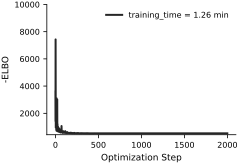

In [18]:
# Plot ELBO convergence
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(-np.array(vi_elbo_history), color='0.15',
        linewidth=2,
        label=f"training_time = {vi_time / 60:.2f} min")
ax.set_ylim(min(-np.array(vi_elbo_history))-100, 1e4)
# ax.set_yscale('log')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
plt.tight_layout()
ax.legend()
finalize_axes(keep_box=False)

The loss decreases but has not fully stabilized. Additional optimization may improve the fit; posterior predictive trajectories are examined below.

### Inference function for amortized VI

AVI replaces separate guide parameters for each data set with a conditional guide $q_{\phi'}(\theta \mid \mathbf{y})$. A neural inference network maps observations to the guide parameters. We train this network by maximizing an amortized evidence lower bound (AELBO), which averages the ELBO over trajectories drawn from the data-generating process:


$$\mathrm{AELBO}(\phi')
=
\mathbb{E}_{p_{\mathrm{train}}(\mathbf{y})}
\Big[
\mathbb{E}_{q_{\phi'}(\theta \mid \mathbf{y})}
\big(
\log p(\mathbf{y}\mid \theta)
+ \log p(\theta)
- \log q_{\phi'}(\theta \mid \mathbf{y})
\big)
\Big].$$


Here, $p_{\mathrm{train}}(\mathbf{y})$ is the distribution of trajectories accepted by the bounds above, $q_{\phi'}(\theta\,|\,\mathbf{y})$ is the guide produced by the inference network, $p(\mathbf{y}\,|\,\theta)$ is the likelihood, and $p(\theta)$ is the prior. We learn $\phi'$ by maximizing this expectation over data sets $\mathbf{y}$ drawn from $p_{\mathrm{train}}(\mathbf{y})$.

The inference network takes the observations as input and returns the mean and covariance parameters of the Gaussian guide. For an $n$-dimensional parameter vector, a lower-triangular Cholesky factor $L$ has $n(n+1)/2$ diagonal and off-diagonal entries.


In [19]:
# Inference function (with inductive bias)
class NeuralNetworkEncoder(eqx.Module):
    """
    Class that represents the inference map from the data to the parameters.
    Encodes a fixed-size input observational data into mean and cov outputs.
    """
    hidden: list[eqx.nn.Linear]
    mu_head: eqx.nn.MLP
    cov_head: eqx.nn.MLP

    priors_mu_theta: tuple[float, ...] = eqx.field(static=True)
    priors_sigma_theta: tuple[float, ...] = eqx.field(static=True)

    out_dim_mu: int = eqx.field(static=True)
    out_dim_cov: int = eqx.field(static=True)
    scales: float = eqx.field(static=True)


    def __init__(self, key, t_len, last_hidden_dim, out_dim_mu, out_dim_cov,
                 hidden_layers=2, branch_depth=2, scales=None,
                 priors_mu_theta=None, priors_sigma_theta=None):
        """
        Args:
            key: Random key
            t_len: Length of input sequence
            last_hidden_dim: Dimension of the final hidden layer (trunk output)
            out_dim_mu: Output dimension for mean
            out_dim_cov: Output dimension for covariance matrix
            hidden_layers: Number of hidden layers in trunk
            branch_depth: Depth of branch MLPs
            scales: Data standardization constant
            priors_mu_theta: Prior means for output bias
            priors_sigma_theta: Prior standard deviations for output bias
        """
        keys = jr.split(key, hidden_layers + 2)
        self.scales = scales
        self.out_dim_mu = out_dim_mu
        self.out_dim_cov = out_dim_cov

        self.priors_mu_theta = (
            priors_mu_theta if priors_mu_theta is not None
            else tuple([0.0] * out_dim_mu))
        self.priors_sigma_theta = (
            priors_sigma_theta if priors_sigma_theta is not None
            else tuple([1.0] * out_dim_mu))

        # Trunk
        self.hidden = []
        prev_dim = t_len
        for i in range(hidden_layers):
            # dimension of the next layer
            next_out_dim = int(
                t_len * (hidden_layers - i - 1) / hidden_layers +
                last_hidden_dim * (i + 1) / hidden_layers
            )

            # Append the layer
            self.hidden.append(
                eqx.nn.Linear(prev_dim, next_out_dim, key=keys[i]))

            # update the dimension for next layer
            prev_dim = next_out_dim


        # Vectorized heads for mean and covariance parameters
        self.mu_head = eqx.nn.MLP(
            last_hidden_dim,
            out_dim_mu,
            width_size=last_hidden_dim // 2,
            depth=branch_depth,
            activation=jax.nn.silu,
            key=keys[hidden_layers],
        )

        self.cov_head = eqx.nn.MLP(
            last_hidden_dim,
            out_dim_cov,
            width_size=last_hidden_dim // 2,
            depth=branch_depth,
            activation=jax.nn.silu,
            key=keys[hidden_layers + 1],
        )

    def __call__(self, x):
        """Process input through the neural network.

        Args:
            x: observations

        Returns:
            mean_output
            covariance_output
        """
        x = x.reshape(-1, 1)

        # Standardize data if scales provided
        if self.scales is not None:
            x = x / self.scales
        x = x.flatten()

        # Process through trunk and branches
        for layer in self.hidden:
            x = jax.nn.silu(layer(x))

        nn_mu = self.mu_head(x)
        nn_cov = self.cov_head(x)

        # Mean: prior mean as bias
        mean_output = jnp.asarray(self.priors_mu_theta) + nn_mu

        # Covariance: diagonal uses prior sigma, off-diagonal 0
        n_diag = len(self.priors_sigma_theta)
        n_off = self.out_dim_cov - n_diag

        cov_bias = jnp.concatenate(
            [jnp.log(jnp.asarray(self.priors_sigma_theta)), jnp.zeros(n_off)])
        cov_mult = jnp.concatenate([2.0*jnp.ones(n_diag), 0.01*jnp.ones(n_off)])
        covariance_output = cov_bias + cov_mult * nn_cov

        log_diag = covariance_output[:n_diag]
        off_diag = covariance_output[n_diag:]

        # Clip to avoid instability
        log_diag = jnp.clip(log_diag, jnp.log(1e-5), jnp.log(10.0))
        covariance_output = jnp.concatenate([log_diag, off_diag])

        return mean_output, covariance_output

We now specify the inference network. Its output is centered on the prior parameters, which provides an inductive bias at initialization.

In [20]:
# Construct inference model with specific architecture
key, subkey = jr.split(key)
inference_model = NeuralNetworkEncoder(
    key = subkey,
    t_len = t_len,
    last_hidden_dim = 300,    # Final hidden dimension of trunk
    out_dim_mu = n_params,
    out_dim_cov = n_params * (n_params + 1) // 2,
    hidden_layers = 2,        # Number of trunk layers
    branch_depth = 2,         # Depth of branch MLPs
    scales = scale_obs,
    priors_mu_theta = tuple(prior_mus.tolist()),
    priors_sigma_theta = tuple(prior_sigmas.tolist()),
)

### AVI Training

Each AVI training step draws a new batch of trajectories, controlled by ``minibatch_size``, and runs ``n_mc_samples`` forward ODE simulations for each trajectory. This computation should be run on a GPU.

We use $1000$ training steps for this example.

In [21]:
# Train AVI inference model
print("\n" + "="*50)
print("Training AVI Model")
print("="*50 )

key, subkey = jr.split(key)
avi_model_trained, avi_elbo_history, avi_training_time = run_vi(
    mode = "amortized",
    key = subkey,
    obs = None,
    ts = ts,
    consts = consts,
    sigma_meas = sigma_meas,
    prior = prior,
    constraint = constraint,
    inference_model = inference_model,
    minibatch_size = 5,
    n_steps = 1000,
    n_mc_samples = 6,
    learning_rate = 1e-4
)


Training AVI Model


Step 100/1000, ELBO: -1.21e+03


Step 200/1000, ELBO: -7.76e+02


Step 300/1000, ELBO: -6.76e+02


Step 400/1000, ELBO: -9.76e+02


...

Step 600/1000, ELBO: -7.65e+02


Step 700/1000, ELBO: -1.38e+03


Step 800/1000, ELBO: -6.00e+02


Step 900/1000, ELBO: -1.42e+03


Step 1000/1000, ELBO: -7.72e+02


The AELBO history during training is shown below.

array([<Axes: xlabel='Optimization Step', ylabel='-ELBO'>], dtype=object)

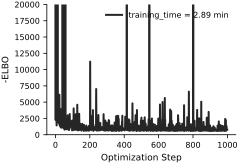

In [22]:
# Visualize AVI training
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(-np.array(avi_elbo_history), color='0.15',
        linewidth=2,
        label=f"training_time = {avi_training_time / 60:.2f} min")
# plt.yscale('log')
ax.set_ylim(0, 2e4)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('-ELBO')
plt.tight_layout()
ax.legend()
finalize_axes(keep_box=False)

The loss oscillates because every training step uses a newly simulated batch. More training data, optimization steps, or network capacity may reduce these oscillations at greater computational cost.

### AVI for the target system

The trained inference network produces guide parameters for the target trajectory in one forward pass.

In [23]:
# Run AVI Inference for target system
avi_mean, avi_L = avi_model_trained(target_obs)
avi_guide_params = jnp.concatenate([avi_mean, avi_L])
avi_guide = FullRankGaussianGuide(avi_guide_params, n_params)

The resulting guide is the AVI approximation for the target trajectory.

### Comparison of VI and AVI

We draw 100 samples from each guide in unconstrained space, transform them to the physical parameter space, and compare them with the generating parameters.

In [24]:
# Sample from posteriors
n_posterior_samples = 100
key, vi_key, avi_key, prior_key = jr.split(key, 4)

# VI samples in unconstrained space
vi_samples_uncon = vi_guide.sample(vi_key, n_posterior_samples)
# Map to constrained space
vi_samples = vmap(lambda z: z_to_theta(constraint, z))(vi_samples_uncon)

# AVI samples in unconstrained space
avi_samples_uncon = avi_guide.sample(avi_key, n_posterior_samples)
# Map to constrained space
avi_samples = vmap(lambda z: z_to_theta(constraint, z))(avi_samples_uncon)

In [25]:
# Sample from priors (in constrained space)
prior_samples = sample_theta_from_prior(prior, prior_key, n_posterior_samples)

The marginal guide distributions are compared with the prior below.

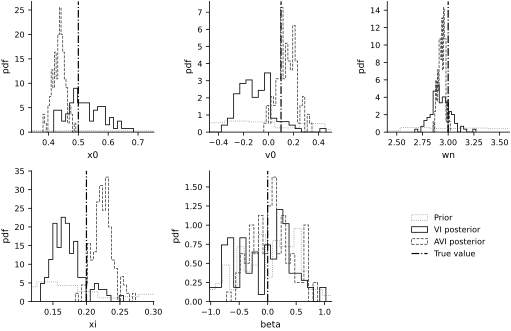

In [26]:
# Visualize posterior distributions
fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZES["full_standard"])
axes = axes.flatten()

for i, name in enumerate(list_theta):
    ax = axes[i]

    # Histograms
    ax.hist(prior_samples[:, i], bins=20, histtype='step',
            label='Prior', density=True, color='0.55', linestyle=':')
    ax.hist(vi_samples[:, i], bins=20, histtype='step',
            label="VI posterior", density=True, color='black', linestyle='-')
    ax.hist(avi_samples[:, i], bins=20, histtype='step',
            label="AVI posterior", density=True, color='0.25', linestyle='--')

    # True value
    ax.axvline(actual_theta[i], color='black',
              linestyle='-.', linewidth=1.2, label='True value')

    # Plot range
    min_range = min(vi_samples[:, i].min(), avi_samples[:, i].min()) * 0.9
    max_range = max(vi_samples[:, i].max(), avi_samples[:, i].max()) * 1.1
    ax.set_xlim(min_range, max_range)
    ax.set_xlabel(name)
    ax.set_ylabel('pdf')

handles, legend_labels = axes[0].get_legend_handles_labels()
axes[5].axis('off')
axes[5].legend(handles, legend_labels, loc='center')
plt.tight_layout()
for ax in axes:
    finalize_axes(keep_box=False)

Samples from each guide induce the following reconstructed trajectories.

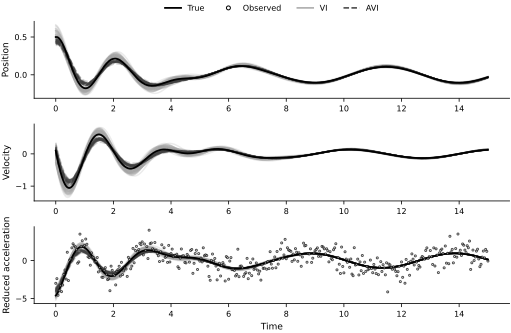

In [27]:
# Compare predicted trajectories using posterior samples (NOT posterior mean)
n_plot = 50  # Samples drawn from posterior
fig, axes = plt.subplots(3, 1, figsize=FIGURE_SIZES["full_standard"])

# VI samples
for th in vi_samples[:n_plot]:
    xs = solve_ode(th, ts, consts)
    axes[0].plot(ts, xs[:, 0], color='0.65', linestyle='-', alpha=0.22)
    axes[1].plot(ts, xs[:, 1], color='0.65', linestyle='-', alpha=0.22)
    axes[2].plot(ts, observation_duffing(th, xs), color='0.65', linestyle='-', alpha=0.22)

# AVI samples
for th in avi_samples[:n_plot]:
    xs = solve_ode(th, ts, consts)
    axes[0].plot(ts, xs[:, 0], color='0.25', linestyle='--', alpha=0.22)
    axes[1].plot(ts, xs[:, 1], color='0.25', linestyle='--', alpha=0.22)
    axes[2].plot(ts, observation_duffing(th, xs), color='0.25', linestyle='--', alpha=0.22)


# True
axes[0].plot(ts, target_xs[:, 0], 'k-', linewidth=1.8, label='True')
axes[1].plot(ts, target_xs[:, 1], 'k-', linewidth=1.8, label='True')
true_acc = observation_duffing(actual_theta, target_xs)
axes[2].plot(ts, true_acc, 'k-', linewidth=1.8, label='True')
axes[2].plot(ts, target_obs, linestyle='none', marker='o', markersize=2,
             markerfacecolor='white', markeredgecolor='black', alpha=0.7,
             label='Observed')

axes[0].set_ylabel('Position')
axes[1].set_ylabel('Velocity')
axes[2].set_ylabel('Reduced acceleration')
axes[2].set_xlabel('Time')

axes[0].plot([], [], linestyle='none', marker='o', markerfacecolor='white',
             markeredgecolor='black', label='Observed')
axes[0].plot([], [], color='0.65', linestyle='-', linewidth=1.5, label='VI')
axes[0].plot([], [], color='0.25', linestyle='--', linewidth=1.5, label='AVI')
axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)

plt.tight_layout()
for ax in axes:
    finalize_axes(keep_box=False)

Both guides reproduce the main oscillatory behavior in this run. Agreement with one target trajectory does not establish that their posterior uncertainty is calibrated. AVI accuracy depends on the expressiveness of the inference network, the training distribution, and the optimization budget.

Standard VI reruns an optimization for every new trajectory. AVI shifts most of that cost to offline training, after which a new trajectory requires one forward pass through the inference network.